## Exploratory Data Analysis

### MedMNIST
* 18x Standardized Datasets for 2D and 3D Biomedical Image Classification
* Covers diverse data modalities, dataset scales (from 100 to 100,000), and tasks (binary/multi-class, multi-label, and ordinal regression)
* Each sub-dataset is pre-processed into the same format, which requires no background knowledge for users. 
* As an MNIST-like dataset collection to perform classification tasks on small images, it primarily focuses on the machine learning part rather than the end-to-end system. 
* Furthermore, we provide standard train-validation-test splits for all datasets in MedMNIST, therefore algorithms could be easily compared.
* Small size of 28×28 (2D) or 28×28×28 (3D) is lightweight and ideal for evaluating machine learning algorithms.
* Larger-size version, MedMNIST+: 64x64 (2D), 128x128 (2D), 224x224 (2D), and 64x64x64 (3D).

### BloodMNIST
* 8 classes
* 17,092 samples
* Source of data: Andrea Acevedo, Anna Merino, et al., "A dataset of microscopic peripheral blood cell images for development of automatic recognition systems," Data in Brief, vol. 30, pp. 105474, 2020.

#### Labels
* 0 = basophil
* 1 = eosinophil
* 2 = erythroblast
* 3 = immature granulocyte
* 4 = lymphocyte
* 5 = monocyte
* 6 = neutrophil
* 7 = platelet

In [1]:
# Path to project directory
path_proj = "/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification"

In [2]:
import medmnist
from medmnist import BloodMNIST
print(medmnist.__version__)

3.0.2


In [3]:
# Download BloodMNIST metadata
from medmnist import INFO
data_flag = "bloodmnist"
info = INFO[data_flag]

In [4]:
# Download BloodMNIST data
train_data = BloodMNIST(split="train", root=f"{path_proj}/data", download=True)
val_data   = BloodMNIST(split="val", root=f"{path_proj}/data", download=True)
test_data  = BloodMNIST(split="test", root=f"{path_proj}/data", download=True)

In [ ]:
# Path to data objects
print(train_data.root)
print(val_data.root)
print(test_data.root)

/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification/data
/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification/data
/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification/data


In [6]:
# Object type
print(type(train_data))
print(type(val_data))
print(type(test_data))

<class 'medmnist.dataset.BloodMNIST'>
<class 'medmnist.dataset.BloodMNIST'>
<class 'medmnist.dataset.BloodMNIST'>


In [7]:
# Extract observations and labels from BloodMNIST object
X_train = train_data.imgs
y_train = train_data.labels.ravel()

X_val = val_data.imgs
y_val = val_data.labels.ravel()

X_test = test_data.imgs
y_test = test_data.labels.ravel()

In [8]:
# Data type
print(type(X_train))
print(type(X_val))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [9]:
# Data shape
print(X_train.shape) # num_samples x height x width x channels
print(y_train.shape) # num_samples x 1

print(X_val.shape) # num_samples x height x width x channels
print(y_val.shape) # num_samples x 1

print(X_test.shape) # num_samples x height x width x channels
print(y_test.shape) # num_samples x 1

(11959, 28, 28, 3)
(11959,)
(1712, 28, 28, 3)
(1712,)
(3421, 28, 28, 3)
(3421,)


In [10]:
# Label counts
import numpy as np

labels, counts = np.unique(y_train, return_counts=True)

for label, count in zip(labels, counts):
    print(label, count)

0 852
1 2181
2 1085
3 2026
4 849
5 993
6 2330
7 1643


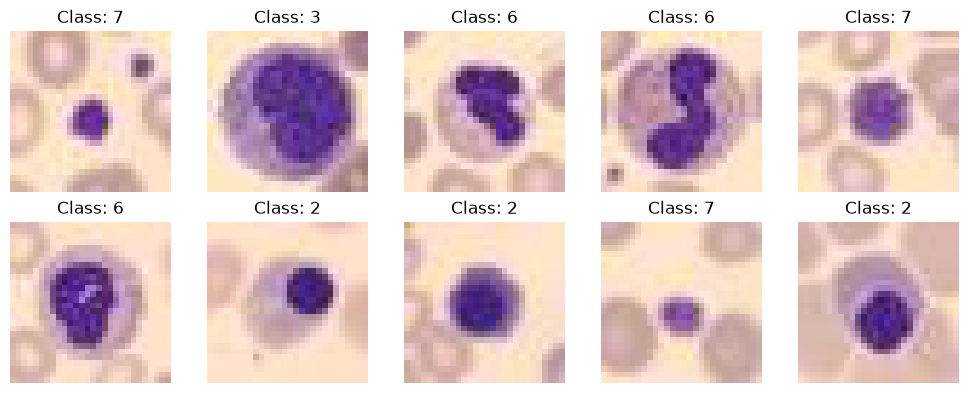

In [11]:
# Plot images
import matplotlib.pyplot as plt

def plot_10_images(X, y):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        # Individual Axes level methods
        ax.imshow(X[i])
        ax.set_title(f"Class: {y[i]}")
        ax.axis("off")
    # Figure level methods
    plt.tight_layout()
    plt.show()

plot_10_images(X_train[0:10], y_train[0:10])

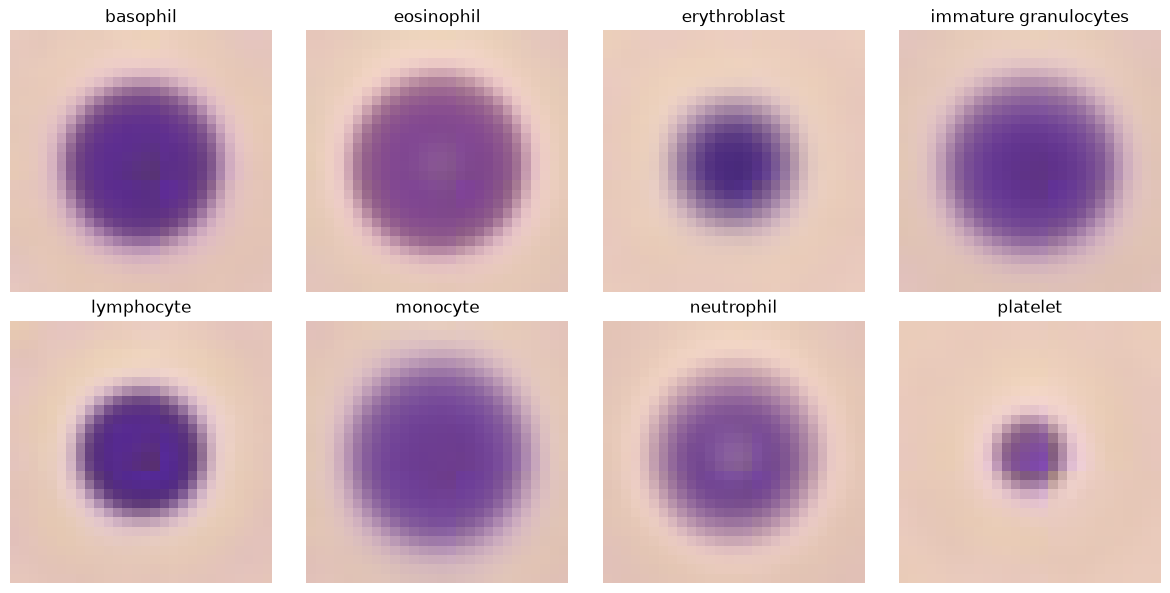

In [12]:
# Mean of images of each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for label, ax in enumerate(axes.flat):
    mean_image = X_train[y_train.ravel() == label].mean(axis=0)
    class_name = info["label"][str(label)]
    if label == 3:
        class_name = "immature granulocytes"
    ax.imshow(mean_image.astype("uint8"))
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

(11959, 2352)


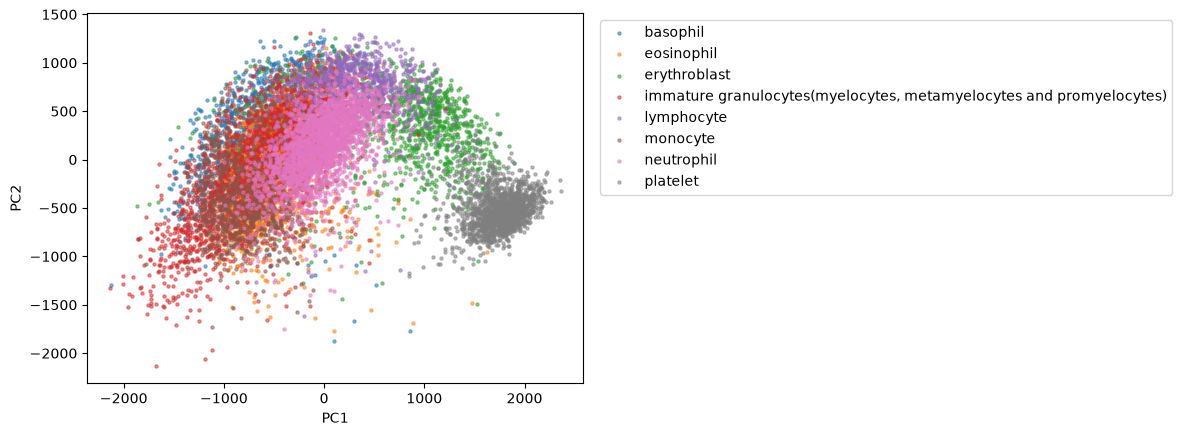

In [13]:
# PCA
X_flat = X_train.reshape(len(X_train), -1)
print(X_flat.shape)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

for label in np.unique(y_train):
    mask = y_train.ravel() == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=5,
        alpha=0.5,
        label=info["label"][str(label)]
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

In [14]:
# UMAP 
import umap
umap_reducer = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, random_state=42)
X_umap = umap_reducer.fit_transform(X_flat)
X_umap.shape # (n_samples, 2)

/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/angdamian/3-Bioinformatics/machine-learning/bloodmnist-classification/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(11959, 2)

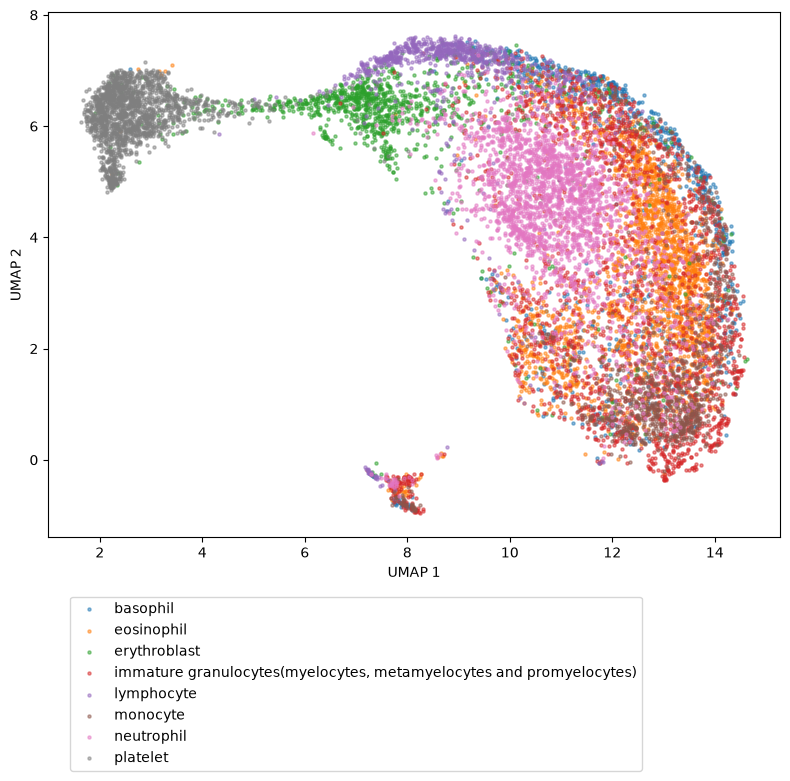

In [15]:
# Plot UMAP
plt.figure(figsize=(8, 8))

for label in np.unique(y_train):
    mask = y_train.ravel() == label

    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=5,
        alpha=0.5,
        label=info["label"][str(label)]
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, -0.1)
)

plt.tight_layout()
plt.show()

# Insights
# Platelets (grey) are strongly separated from the other cells 